In [2]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf

# -----------------------------------------------------------------------------
# Paths to trained NN artifacts (produced in 3.1.2 Classification Model Development)
# Update these if you relocate the saved model bundle.
MODEL_DIR = Path("/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_nn_classifier")
MODEL_PATH = MODEL_DIR / "pattern_classifier.keras"
SCALER_PATH = MODEL_DIR / "scaler.joblib"
ENCODER_PATH = MODEL_DIR / "label_encoder.joblib"

# Path to the embeddings you want to classify (e.g., cluster centroids, code snippets).
INFERENCE_SOURCE_PATH = Path(
    "/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/experiments-llm/results/pattern_embeddings/gemini_communities_embedding.csv"
)

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")
if not SCALER_PATH.exists() or not ENCODER_PATH.exists():
    raise FileNotFoundError("Scaler/encoder artifacts missing. Re-run the training notebook to regenerate them.")
if not INFERENCE_SOURCE_PATH.exists():
    raise FileNotFoundError(
        "Inference source CSV not found. Update INFERENCE_SOURCE_PATH to point to your embedding dataset."
    )


2025-12-08 21:19:02.152043: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# Load the embeddings to classify
inference_df = pd.read_csv(INFERENCE_SOURCE_PATH)
numeric_columns = inference_df.select_dtypes(include=[np.number]).columns.tolist()
if not numeric_columns:
    raise ValueError("No numeric columns detected in the inference dataset.")

context_columns = [col for col in inference_df.columns if col not in numeric_columns]
feature_matrix = inference_df[numeric_columns].fillna(0.0).values
print(
    f"Loaded {feature_matrix.shape[0]} samples with {feature_matrix.shape[1]} numeric features (context cols: {context_columns})."
)

Loaded 2442 samples with 768 numeric features (context cols: ['pattern', 'file']).


In [4]:
def load_pattern_classifier(
    model_path: Path = MODEL_PATH,
    scaler_path: Path = SCALER_PATH,
    encoder_path: Path = ENCODER_PATH,
):
    """Load the saved NN, scaler, and label encoder for inference."""
    model = tf.keras.models.load_model(model_path)
    scaler = joblib.load(scaler_path)
    encoder = joblib.load(encoder_path)
    return model, scaler, encoder


def predict_pattern_probabilities(
    embeddings: np.ndarray,
    model: tf.keras.Model,
    scaler: StandardScaler,
    encoder: LabelEncoder,
) -> pd.DataFrame:
    """Return class probability dataframe for the provided embeddings."""
    embeddings = np.atleast_2d(embeddings)
    scaled = scaler.transform(embeddings)
    probs = model.predict(scaled)
    return pd.DataFrame(probs, columns=encoder.classes_)

In [5]:
loaded_model, loaded_scaler, loaded_encoder = load_pattern_classifier()
probs_df = predict_pattern_probabilities(feature_matrix, loaded_model, loaded_scaler, loaded_encoder)

results_df = pd.concat([
    inference_df[context_columns].reset_index(drop=True) if context_columns else pd.DataFrame(index=probs_df.index),
    probs_df,
], axis=1)

print("Preview of class probability outputs:")
display(results_df.head())

OUTPUT_PATH = INFERENCE_SOURCE_PATH.with_name(f"{INFERENCE_SOURCE_PATH.stem}_classified.csv")
results_df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved classification results to {OUTPUT_PATH}")

2025-12-08 21:19:24.132624: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Preview of class probability outputs:


,pattern,file,Advanced LLM Prompting,Cross-lingual LLM Prompting,Enhanced User Intent Comprehension with LLMs,Explainable AI (XAI) Techniques,Integrating External Knlowladge with LLM,LLM Agent Training & Alignment,LLM Code Execution for Precision,LLM Context Management,LLM KV Cache Optimization,LLM Results Evaluation,LLM based Multimodal Generative Prompting,"LLM based Planning, Iterative Optimizations and ReAct, or Reasoning, Think Step by step, XoT",LLMs for Recommender Systems,Modular LLM Agent Architectures,"Reliable, Transparent, & Augmented LLMs",Retrieval Augmented Generation(RAG) Optimization for LLMs,Structured Output & Formatting for LLMs,Tool Use for LLMs
0,3DOD_thesis,3DOD_thesis/cluster_0.py,0.014984,0.014582,0.001922,0.008451,0.002866,0.003040,0.001390,0.016106,0.005177,0.080830,0.486824,0.016700,0.002741,0.001580,0.085692,0.060102,0.003234,0.193779
1,3DOD_thesis,3DOD_thesis/cluster_1.py,0.156626,0.017724,0.008375,0.027097,0.023834,0.003932,0.009534,0.014380,0.014012,0.107218,0.249592,0.068378,0.015210,0.006519,0.040351,0.048506,0.003941,0.184770
2,3DOD_thesis,3DOD_thesis/cluster_10.py,0.010698,0.009680,0.001751,0.006264,0.002580,0.004074,0.001007,0.015690,0.009334,0.088640,0.562037,0.022227,0.002538,0.001881,0.087727,0.047862,0.002927,0.123084
3,3DOD_thesis,3DOD_thesis/cluster_2.py,0.162468,0.012174,0.017557,0.048421,0.005195,0.004811,0.026025,0.036991,0.097109,0.090363,0.018719,0.102640,0.007772,0.066003,0.168908,0.029084,0.073755,0.032004
4,3DOD_thesis,3DOD_thesis/cluster_3.py,0.000273,0.000298,0.000324,0.005475,0.000109,0.000109,0.000761,0.000647,0.000068,0.004468,0.008687,0.001108,0.000217,0.000403,0.964763,0.000988,0.000136,0.011166


Saved classification results to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/experiments-llm/results/pattern_embeddings/gemini_communities_embedding_classified.csv


In [6]:
results_df['Predicted Pattern'] = results_df[loaded_encoder.classes_].idxmax(axis=1)

/tmp/ipykernel_263057/2980913650.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


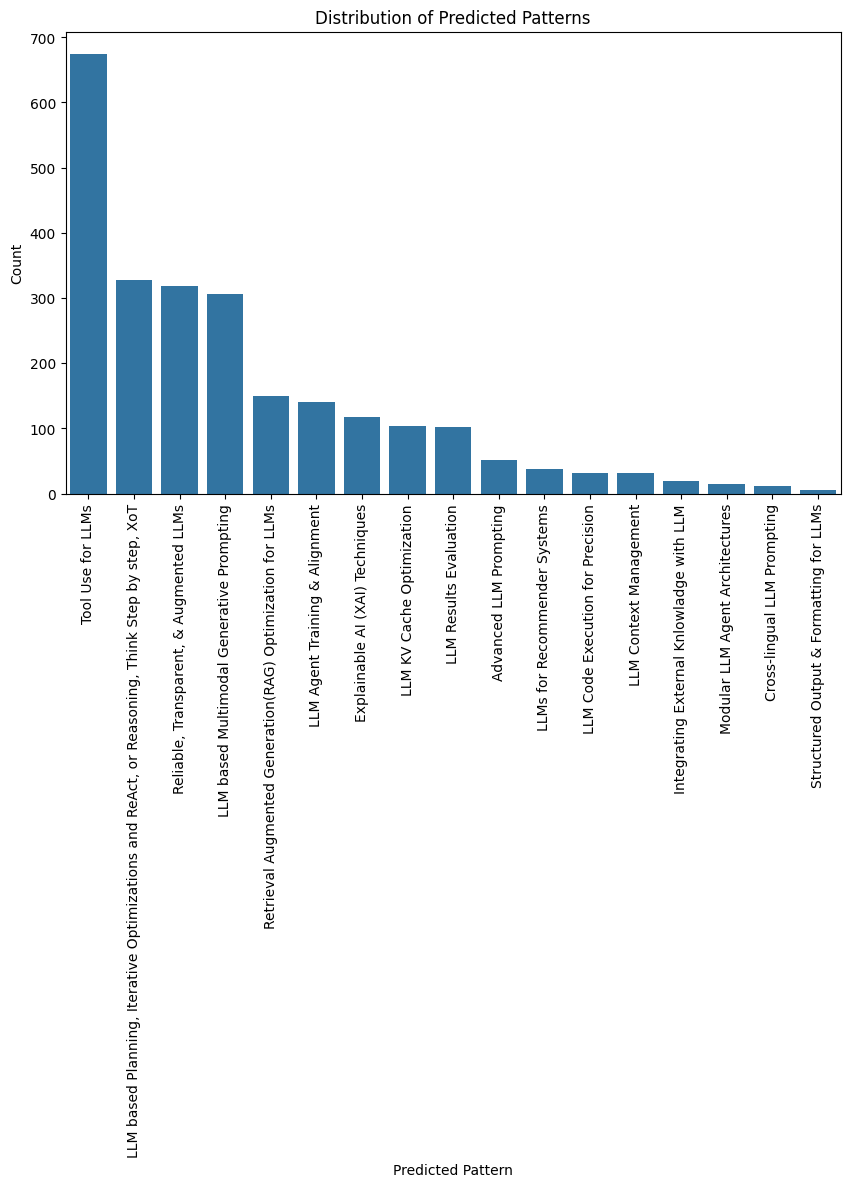

In [8]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=results_df, x='Predicted Pattern', order=results_df['Predicted Pattern'].value_counts().index)
plt.title('Distribution of Predicted Patterns')
plt.xlabel('Predicted Pattern')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()